In [1]:
import fdasrsf as fs
import numpy as np
import matplotlib.pyplot as plt

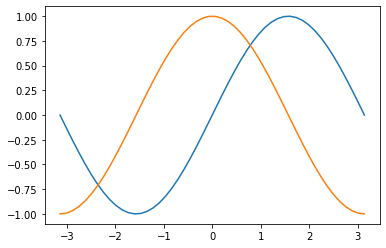

In [2]:
time = np.linspace(-np.pi, np.pi)
f1 = np.sin(time)
f2 = np.cos(time)
plt.plot(time,f1,time,f2)
plt.show()

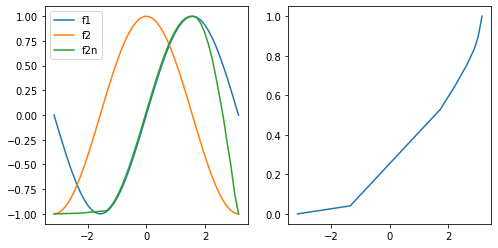

In [3]:
f2n, gam,_ = fs.pairwise_align_functions(f1,f2,time)
fig, axs = plt.subplots(1,2,figsize=(2*4,4))
axs[0].plot(time, f1,label='f1')
axs[0].plot(time, f2,label='f2')
axs[0].plot(time, f2n,label='f2n')
axs[1].plot(time, gam)
axs[0].legend()
plt.show()

In [16]:
q1 = fs.f_to_srsf(f1, time)
q2 = fs.f_to_srsf(f2, time)

gam = fs.optimum_reparam(q1, time, q2, "RBFGS", lam=5e-4)
fw = fs.warp_f_gamma(time, f2, gam)
qw = fs.warp_q_gamma(time, q2, gam)

da = np.sqrt(np.trapz((qw - q1) ** 2, time))
M = time.shape[0]
t = np.linspace(0,1,M)
psi = np.sqrt(np.gradient(gam,time))
q1dotq2 = np.trapz(psi, t)
if q1dotq2 > 1:
    q1dotq2 = 1
elif q1dotq2 < -1:
    q1dotq2 = -1

dp = np.real(np.arccos(q1dotq2))
print('Amplitude distance: %.2f, Phase distance: %.2f'%(da,dp))

Amplitude distance: 2.30, Phase distance: 1.18


 /Users/pozzolabadmin/Documents/codebase/HEAD/ext/fdasrsf_python/fdasrsf/rbfgs.py:196: RuntimeWarning:invalid value encountered in true_divide
 /Users/pozzolabadmin/Documents/codebase/HEAD/ext/fdasrsf_python/fdasrsf/rbfgs.py:197: RuntimeWarning:divide by zero encountered in true_divide
 /Users/pozzolabadmin/Documents/codebase/HEAD/ext/fdasrsf_python/fdasrsf/rbfgs.py:197: RuntimeWarning:invalid value encountered in true_divide


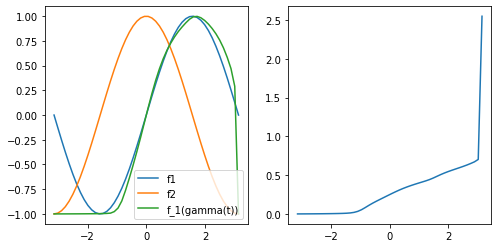

In [18]:
fig, axs = plt.subplots(1,2,figsize=(2*4,4))
axs[0].plot(time, f1,label='f1')
axs[0].plot(time, f2,label='f2')
axs[0].plot(time, fw,label='f_1(gamma(t))')
axs[1].plot(time, gam)
axs[0].legend()
plt.show()